<a href="https://colab.research.google.com/github/chaitanyamuniraju077-debug/olist-sales-analysis/blob/main/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
df.isnull().sum()


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
print(df["gender"].unique())
print(df["race/ethnicity"].unique())
print(df["parental level of education"].unique())
print(df["lunch"].unique())
print(df["test preparation course"].unique())

['female' 'male']
['group B' 'group C' 'group A' 'group D' 'group E']
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
['standard' 'free/reduced']
['none' 'completed']


In [ ]:
# 5-Line Summary of the Dataset
print(f"1. The dataset contains {df.shape[0]} student records and {df.shape[1]} features.")
print(f"2. Total missing values across the dataset: {df.isnull().sum().sum()}")
print(f"3. Total duplicate rows found: {df.duplicated().sum()}")
print(f"4. The average math score is {df['math score'].mean():.2f}, with scores ranging from {df['math score'].min()} to {df['math score'].max()}.")
print(f"5. The dataset includes categorical data regarding demographics, parental education, lunch types, and test preparation courses.")

1. The dataset contains 1000 student records and 8 features.
2. Total missing values across the dataset: 0
3. Total duplicate rows found: 0
4. The average math score is 66.09, with scores ranging from 0 to 100.
5. The dataset includes categorical data regarding demographics, parental education, lunch types, and test preparation courses.


In [ ]:
# Q1: Parental education vs. Exam scores
parental_edu_scores = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()
parental_edu_scores

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [ ]:
# Q2: Test preparation course vs. Exam scores
test_prep_scores = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()
test_prep_scores

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
# Q3: Correlation between math, reading, and writing scores
score_columns = ['math score', 'reading score', 'writing score']
correlation_matrix = df[score_columns].corr()
correlation_matrix

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [ ]:
# Q4: Gender performance comparison across subjects
gender_performance = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
gender_performance

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [ ]:
# Q5: Create a total score column and find its distribution/stats
df['total score'] = df['math score'] + df['reading score'] + df['writing score']

# View summary statistics for the total score
print(df['total score'].describe())


count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: total score, dtype: float64


/tmp/ipykernel_574/3401955219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='parental level of education', y='math score', data=df, palette='Set2')


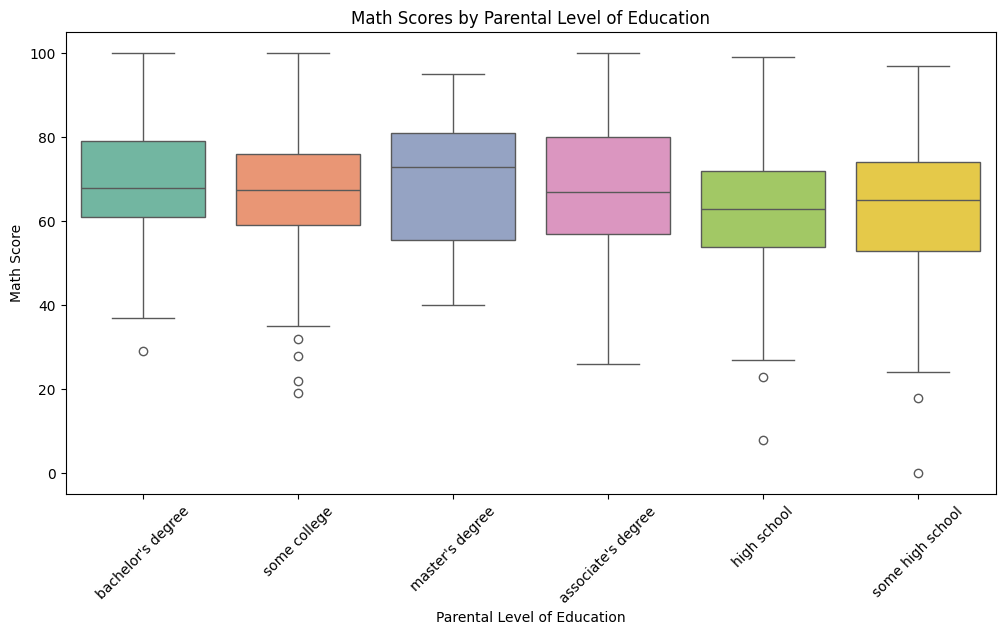

/tmp/ipykernel_574/3401955219.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='test preparation course', y='total score', data=test_prep_avg, palette='Blues')


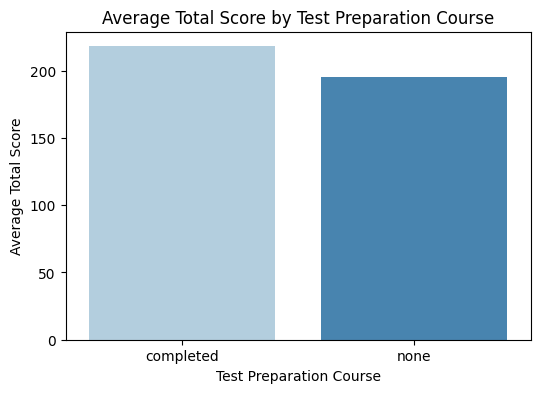

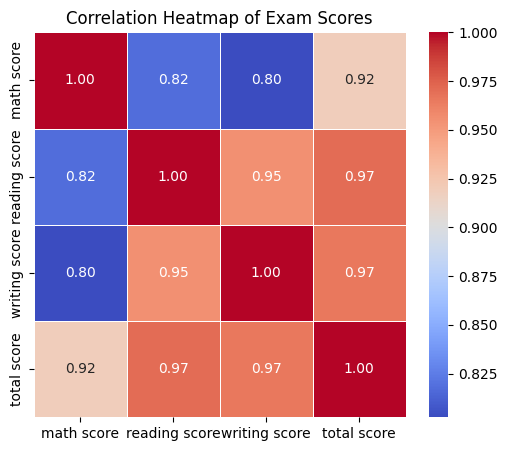

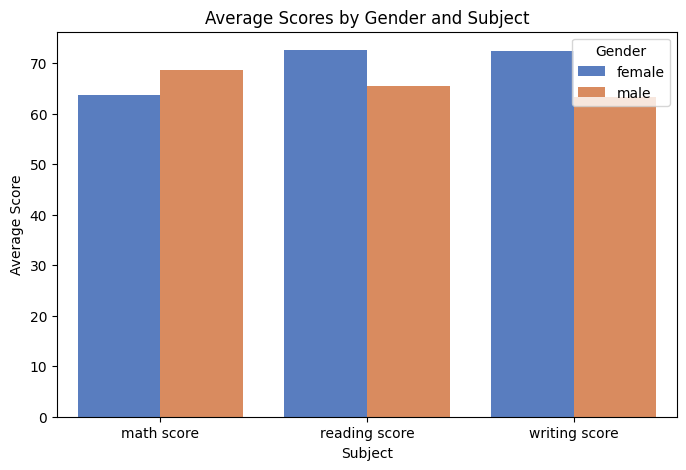

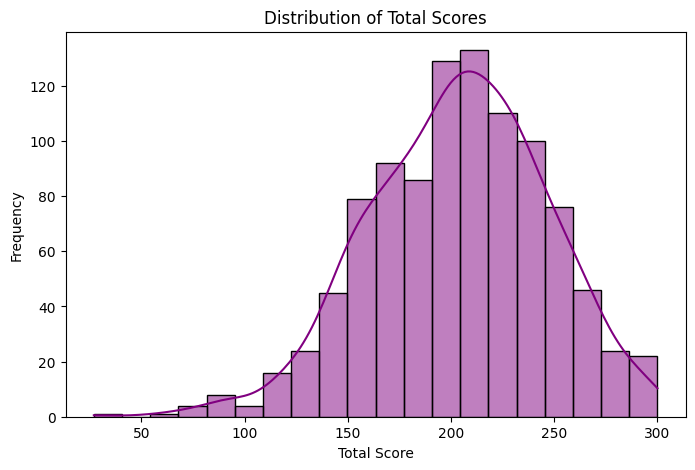

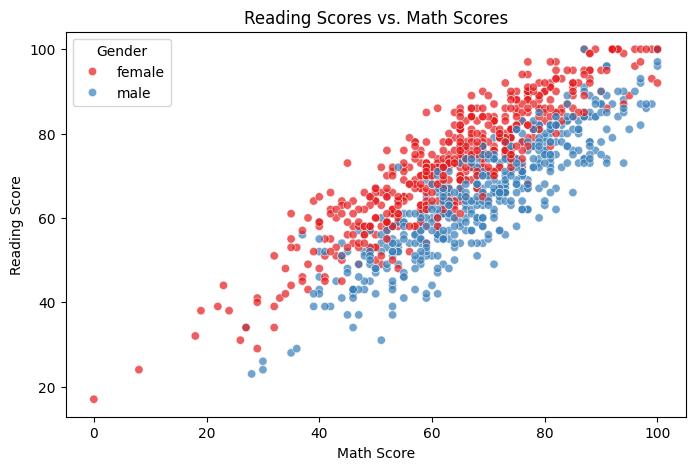

In [ ]:
# Chart 1: Box plot of math scores by parental level of education
plt.figure(figsize=(12, 6))
sns.boxplot(x='parental level of education', y='math score', data=df, palette='Set2')
plt.title('Math Scores by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Math Score')
plt.xticks(rotation=45)
plt.show()
# Chart 2: Bar chart comparing average total scores by test preparation course
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
test_prep_avg = df.groupby('test preparation course')['total score'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(x='test preparation course', y='total score', data=test_prep_avg, palette='Blues')
plt.title('Average Total Score by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Average Total Score')
plt.show()
# Chart 3: Correlation heatmap for exam scores
plt.figure(figsize=(6, 5))
score_columns = ['math score', 'reading score', 'writing score', 'total score']
sns.heatmap(df[score_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Exam Scores')
plt.show()
# Chart 4: Grouped bar chart comparing gender performance across subjects
gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean().reset_index()
gender_melted = gender_scores.melt(id_vars='gender', value_vars=['math score', 'reading score', 'writing score'],
                                   var_name='Subject', value_name='Average Score')

plt.figure(figsize=(8, 5))
sns.barplot(x='Subject', y='Average Score', hue='gender', data=gender_melted, palette='muted')
plt.title('Average Scores by Gender and Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Gender')
plt.show()
# Chart 5: Histogram with KDE curve for total score distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['total score'], kde=True, color='purple', bins=20)
plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.show()
# Chart 6: Scatter plot comparing reading scores and math scores
plt.figure(figsize=(8, 5))
sns.scatterplot(x='math score', y='reading score', hue='gender', data=df, alpha=0.7, palette='Set1')
plt.title('Reading Scores vs. Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.legend(title='Gender')
plt.show()

In [ ]:
# Define at-risk: scoring below 50 in any subject
df['is_at_risk'] = (df['math score'] < 50) | (df['reading score'] < 50) | (df['writing score'] < 50)

# Count how many students are at-risk
total_at_risk = df['is_at_risk'].sum()
print(f"Total number of at-risk students: {total_at_risk} out of {len(df)}")

Total number of at-risk students: 188 out of 1000


In [ ]:
# At-risk percentage by lunch type (often a proxy for socio-economic status)
lunch_risk = df.groupby('lunch')['is_at_risk'].mean() * 100
print("At-risk percentage by lunch type:")
print(lunch_risk)
print("\n" + "-"*40 + "\n")

# At-risk percentage by test preparation course
prep_risk = df.groupby('test preparation course')['is_at_risk'].mean() * 100
print("At-risk percentage by test preparation course:")
print(prep_risk)

At-risk percentage by lunch type:
lunch
free/reduced    31.267606
standard        11.937984
Name: is_at_risk, dtype: float64

----------------------------------------

At-risk percentage by test preparation course:
test preparation course
completed    10.055866
none         23.676012
Name: is_at_risk, dtype: float64


# Principal's School Performance Report

## Executive Summary
As requested by the school principal, this data-driven report analyzes student performance records to identify critical factors affecting grades and pinpoint at-risk students. By examining demographic trends, test preparation outcomes, and core subject scores, we have uncovered vital areas requiring institutional intervention. Implementing the targeted recommendations outlined in this report will significantly improve academic outcomes and student support for the upcoming academic year.

## 5 Key Findings
1. **Parental Education Impact:** Students whose parents attained higher levels of education (such as a bachelor's or master's degree) consistently achieved higher average scores across math, reading, and writing.
2. **Test Preparation Benefits:** Students who completed the test preparation course scored noticeably higher on average and experienced a lower rate of failing grades.
3. **Socio-Economic Disparities:** Socio-economic status—proxied by lunch type—heavily influences performance, with students on standard lunch plans outperforming those on free or reduced lunch plans.
4. **Cross-Subject Correlation:** There is a very strong positive correlation between reading, writing, and math scores; students struggling in one discipline typically underperform across the board.
5. **At-Risk Concentration:** A significant cluster of students falls into the "at-risk" category (scoring below 50 in any subject), with failure rates heavily concentrated among those who skipped test preparation and lower-income demographics.

## 3 Specific Actionable Recommendations
1. **Implement Mandatory, Free Test Prep Workshops:** The school should subsidize and mandate test preparation workshops for all students to close the performance gap seen in non-participants.
2. **Establish Early-Warning Intervention Programs:** Create a targeted tutoring and support system triggered early in the semester for students identified as at-risk based on socio-economic indicators or baseline test metrics.
3. **Enhance Parental Engagement:** Launch community outreach and academic alignment seminars to help parents better support their children's studies at home, bridging the gap tied to parental education levels.